## Fine-Tuning DistilBERT for IMDb Sentiment Classification

**Student:** Salla Tarun Kumar  
**Student number:** 23082746  
**Module:** Research Methods In Data Science (7PAM2015) — Large Language Models   
**Task:** Binary sentiment classification  
**Dataset:** Stanford IMDb Movie Reviews from Hugging Face  
**Transformer model:** Fine-tuned DistilBERT  
**Comparison models:** TF-IDF Logistic Regression and TF-IDF Multinomial Naïve Bayes  

### Research question

**How effectively does a fine-tuned DistilBERT model classify IMDb movie reviews as positive or negative compared with tuned traditional text-classification baselines?**

### Hypothesis

DistilBERT is expected to achieve the strongest F1-score because its bidirectional contextual representations can model context, negation and word order more effectively than sparse TF-IDF features. However, the expected performance gain must be evaluated against its greater computational cost.

### Dataset source

The public dataset is loaded directly from the Hugging Face Dataset Hub:

```python
load_dataset("stanfordnlp/imdb")
```

Dataset card: `https://huggingface.co/datasets/stanfordnlp/imdb`  

In [ ]:
!pip -q install -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.2 MB/s eta 0:00:00


In [ ]:
import gc
import json
import os
import platform
import random
import re
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset

import datasets
import transformers
from datasets import load_dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from scipy.stats import binomtest
from IPython.display import display
from tqdm.auto import tqdm

print('Imports completed.')

Imports completed.


## 1.1 Reproducible configuration

- `quick`: checks the full pipeline.
- `submission`: recommended balance of quality and Colab runtime.
- `full`: uses the complete official labelled dataset and may take much longer.


In [ ]:
RUN_MODE = 'submission'  # 'quick', 'submission', or 'full'

@dataclass(frozen=True)
class ExperimentConfig:
    """Store all experiment choices in one visible, reproducible object."""
    seed: int = 42
    dataset_name: str = 'stanfordnlp/imdb'
    model_name: str = 'distilbert/distilbert-base-uncased'
    output_dir: str = '/content/Salla_Tarun_Kumar_23082746_LLM_outputs'

    train_size: Optional[int] = 12_000
    validation_size: Optional[int] = 3_000
    test_size: Optional[int] = 5_000

    max_length: int = 256
    batch_size: int = 16
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    epochs: int = 3
    warmup_ratio: float = 0.10
    max_grad_norm: float = 1.0
    early_stopping_patience: int = 1
    use_amp: bool = True

    run_transformer_tuning: bool = True
    tuning_train_size: int = 3_000
    tuning_validation_size: int = 1_000
    tuning_epochs: int = 1
    bootstrap_iterations: int = 500

if RUN_MODE == 'quick':
    CONFIG = ExperimentConfig(
        train_size=4_000, validation_size=1_000, test_size=2_000,
        epochs=2, tuning_train_size=1_500, tuning_validation_size=500,
        bootstrap_iterations=200,
    )
elif RUN_MODE == 'submission':
    CONFIG = ExperimentConfig()
elif RUN_MODE == 'full':
    CONFIG = ExperimentConfig(
        train_size=20_000, validation_size=5_000, test_size=25_000,
        tuning_train_size=4_000, tuning_validation_size=1_000,
        bootstrap_iterations=1_000,
    )
else:
    raise ValueError("RUN_MODE must be 'quick', 'submission', or 'full'.")

OUTPUT_DIR = Path(CONFIG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame([asdict(CONFIG)]).T.rename(columns={0: 'Value'}))

,Value
seed,42
dataset_name,stanfordnlp/imdb
model_name,distilbert/distilbert-base-uncased
output_dir,/content/Salla_Tarun_Kumar_23082746_LLM_outputs
train_size,12000
validation_size,3000
test_size,5000
max_length,256
batch_size,16
learning_rate,0.00002


In [ ]:
def set_global_seed(seed: int) -> None:
    """Set Python, NumPy and PyTorch seeds to reduce run-to-run variation."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_global_seed(CONFIG.seed)
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
    else 'cpu'
)
print('Device:', DEVICE)
if DEVICE.type != 'cuda':
    print('WARNING: Enable a Colab GPU before final transformer training.')

Device: cuda


In [ ]:
environment = {
    'python': platform.python_version(),
    'platform': platform.platform(),
    'torch': torch.__version__,
    'transformers': transformers.__version__,
    'datasets': datasets.__version__,
    'scikit_learn': sklearn.__version__,
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'device': str(DEVICE),
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available',
}
display(pd.DataFrame(environment.items(), columns=['Component', 'Version / value']))
with open(OUTPUT_DIR / 'environment.json', 'w', encoding='utf-8') as file:
    json.dump(environment, file, indent=2)

,Component,Version / value
0,python,3.12.13
1,platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,torch,2.11.0+cu128
3,transformers,5.14.1
4,datasets,5.0.1
5,scikit_learn,1.6.1
6,pandas,2.2.2
7,numpy,2.0.2
8,device,cuda
9,gpu,Tesla T4


# 2. Dataset loading, de-duplication and experimental design

The Stanford IMDb dataset contains labelled negative (`0`) and positive (`1`) movie reviews. The official labelled training and test collections are loaded from Hugging Face.

Before sampling or splitting, exact duplicate reviews are removed after minimal normalisation. Reviews appearing in the official training collection are also removed from the test collection. This conservative procedure prevents identical text from appearing in model development and final evaluation.

The cleaned training collection is divided into stratified training and validation sets. The cleaned official test collection remains untouched until all model and hyperparameter choices are fixed.

Minimal normalisation removes HTML line-break tags and repeated whitespace. Stopwords, punctuation and case-sensitive information are otherwise preserved because negation and sentence structure may carry sentiment.

In [ ]:
raw_dataset = load_dataset(CONFIG.dataset_name)

print(raw_dataset)
print("Label names:", raw_dataset["train"].features["label"].names)
print("Example review:")
print(raw_dataset["train"][0]["text"][:400])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Label names: ['neg', 'pos']
Example review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name


In [ ]:
def normalise_review(text: str) -> str:
    """
    Apply minimal, task-appropriate text normalisation.

    HTML line-break tags and repeated whitespace are removed. Aggressive
    stemming, stopword removal and punctuation deletion are avoided because
    they could remove sentiment-bearing expressions such as negation.
    """
    text = re.sub(r"<br\s*/?>", " ", str(text), flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


def hf_split_to_dataframe(dataset_split) -> pd.DataFrame:
    """Convert a Hugging Face split into a validated pandas dataframe."""
    frame = dataset_split.to_pandas()[["text", "label"]].copy()
    frame["text"] = frame["text"].map(normalise_review)
    frame["label"] = frame["label"].astype(int)
    frame = frame[frame["text"].str.len() > 0].reset_index(drop=True)
    return frame


def remove_exact_duplicates(
    development_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, int]]:
    """
    Remove exact duplicates within and across the labelled collections.

    Development data receive priority. Any test review whose normalised text
    appears in development data is excluded, protecting the final evaluation
    from exact-text leakage.
    """
    original_development_rows = len(development_frame)
    original_test_rows = len(test_frame)

    clean_development = development_frame.drop_duplicates(
        subset="text", keep="first"
    ).reset_index(drop=True)

    clean_test = test_frame.drop_duplicates(
        subset="text", keep="first"
    ).reset_index(drop=True)

    development_texts = set(clean_development["text"])
    cross_collection_overlap = int(clean_test["text"].isin(development_texts).sum())

    clean_test = clean_test[
        ~clean_test["text"].isin(development_texts)
    ].reset_index(drop=True)

    audit = {
        "development_duplicates_removed": original_development_rows - len(clean_development),
        "test_duplicates_removed": original_test_rows - len(test_frame.drop_duplicates(subset="text")),
        "cross_collection_overlaps_removed_from_test": cross_collection_overlap,
    }
    return clean_development, clean_test, audit


def balanced_frame_sample(
    frame: pd.DataFrame,
    requested_size: Optional[int],
    seed: int,
) -> pd.DataFrame:
    """
    Select an exactly balanced, reproducible sample without replacement.

    Balanced subsets ensure that accuracy is interpretable and that model
    comparisons are not driven by a majority class. When the full mode is used,
    the largest possible balanced sample is selected.
    """
    available_per_class = frame["label"].value_counts().min()

    if requested_size is None:
        per_class = int(available_per_class)
    else:
        requested_size = min(int(requested_size), int(available_per_class * 2))
        requested_size -= requested_size % 2
        per_class = requested_size // 2

    parts = [
        frame[frame["label"] == label_value].sample(
            n=per_class,
            replace=False,
            random_state=seed + label_value,
        )
        for label_value in (0, 1)
    ]

    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )


development_full = hf_split_to_dataframe(raw_dataset["train"])
test_full = hf_split_to_dataframe(raw_dataset["test"])

development_clean, test_clean, duplicate_removal_audit = remove_exact_duplicates(
    development_full,
    test_full,
)

# Created one stratified development split before selecting bounded run-mode samples.
development_train, development_validation = train_test_split(
    development_clean,
    test_size=0.20,
    random_state=CONFIG.seed,
    stratify=development_clean["label"],
)

train_df = balanced_frame_sample(
    development_train.reset_index(drop=True),
    CONFIG.train_size,
    CONFIG.seed,
)
validation_df = balanced_frame_sample(
    development_validation.reset_index(drop=True),
    CONFIG.validation_size,
    CONFIG.seed + 1,
)
test_df = balanced_frame_sample(
    test_clean,
    CONFIG.test_size,
    CONFIG.seed + 2,
)

print("Duplicate-removal audit:")
display(pd.DataFrame([duplicate_removal_audit]))

print("Final experimental split sizes:")
print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(validation_df):,}")
print(f"Test:       {len(test_df):,}")

Duplicate-removal audit:


,development_duplicates_removed,test_duplicates_removed,cross_collection_overlaps_removed_from_test
0,98,201,123


Final experimental split sizes:
Train:      12,000
Validation: 3,000
Test:       5,000


## 2.1 Dataset structure and representative observations

The IMDb dataset contains movie-review text and a binary sentiment label. The following output presents the original Hugging Face splits, feature definitions, representative observations and the exact cleaned subsets used in the experiment. Review excerpts are shortened only for display; full texts are retained for modelling.

In [ ]:
dataset_structure = pd.DataFrame([
    {
        "split": split_name,
        "rows": len(dataset_split),
        "columns": ", ".join(dataset_split.column_names),
    }
    for split_name, dataset_split in raw_dataset.items()
])

print("Original Hugging Face dataset structure")
display(dataset_structure)

print("Feature definitions")
print(raw_dataset["train"].features)
print("\nLabels: 0 = Negative, 1 = Positive")

sample_reviews = pd.concat([
    train_df[train_df["label"] == 0].head(3),
    train_df[train_df["label"] == 1].head(3),
]).copy()

sample_reviews["sentiment"] = sample_reviews["label"].map({
    0: "Negative",
    1: "Positive",
})
sample_reviews["review_excerpt"] = (
    sample_reviews["text"].str.slice(0, 250) + "..."
)

print("\nRepresentative observations")
display(sample_reviews[["review_excerpt", "label", "sentiment"]])

experimental_split_summary = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(train_df),
        "negative": int((train_df["label"] == 0).sum()),
        "positive": int((train_df["label"] == 1).sum()),
    },
    {
        "split": "Validation",
        "rows": len(validation_df),
        "negative": int((validation_df["label"] == 0).sum()),
        "positive": int((validation_df["label"] == 1).sum()),
    },
    {
        "split": "Test",
        "rows": len(test_df),
        "negative": int((test_df["label"] == 0).sum()),
        "positive": int((test_df["label"] == 1).sum()),
    },
])

print("\nCleaned experimental subsets")
display(experimental_split_summary)

dataset_structure.to_csv(
    OUTPUT_DIR / "dataset_structure.csv",
    index=False,
)
experimental_split_summary.to_csv(
    OUTPUT_DIR / "experimental_split_summary.csv",
    index=False,
)

Original Hugging Face dataset structure


,split,rows,columns
0,train,25000,"text, label"
1,test,25000,"text, label"
2,unsupervised,50000,"text, label"


Feature definitions
{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Labels: 0 = Negative, 1 = Positive

Representative observations


,review_excerpt,label,sentiment
0,"Sean, you know I think that you are absolutely...",0,Negative
2,Some fraud girl tries to compete in the big le...,0,Negative
4,Whatever his name is (the writer and director)...,0,Negative
1,"""Life hits us in the face........we must try t...",1,Positive
3,My father grew grew up watching George Reeves ...,1,Positive
5,This silly movie is really fun for the younger...,1,Positive



Cleaned experimental subsets


,split,rows,negative,positive
0,Train,12000,6000,6000
1,Validation,3000,1500,1500
2,Test,5000,2500,2500


## 2.2 Data-quality and leakage validation

The checks below verify valid labels, non-empty text, class counts, within-split duplicates and exact cross-split overlap.

The final assertion intentionally stops execution if leakage remains. This is preferable to silently producing an invalid test score.

In [ ]:
def audit_split(frame: pd.DataFrame, name: str) -> Dict[str, object]:
    """Create a concise data-quality report for one experimental split."""
    return {
        "split": name,
        "rows": len(frame),
        "missing_text": int(frame["text"].isna().sum()),
        "empty_text": int(frame["text"].fillna("").str.strip().eq("").sum()),
        "missing_label": int(frame["label"].isna().sum()),
        "valid_binary_labels": set(frame["label"].dropna().unique()).issubset({0, 1}),
        "duplicates_within_split": int(frame["text"].duplicated().sum()),
        "negative_reviews": int((frame["label"] == 0).sum()),
        "positive_reviews": int((frame["label"] == 1).sum()),
    }


data_quality_table = pd.DataFrame([
    audit_split(train_df, "Train"),
    audit_split(validation_df, "Validation"),
    audit_split(test_df, "Test"),
])
display(data_quality_table)

overlap_table = pd.DataFrame({
    "comparison": ["Train ∩ Validation", "Train ∩ Test", "Validation ∩ Test"],
    "exact_text_overlap": [
        len(set(train_df["text"]) & set(validation_df["text"])),
        len(set(train_df["text"]) & set(test_df["text"])),
        len(set(validation_df["text"]) & set(test_df["text"])),
    ],
})
display(overlap_table)

assert data_quality_table["missing_text"].sum() == 0, "Missing text remains."
assert data_quality_table["empty_text"].sum() == 0, "Empty text remains."
assert data_quality_table["missing_label"].sum() == 0, "Missing labels remain."
assert data_quality_table["duplicates_within_split"].sum() == 0, "Within-split duplicates remain."
assert overlap_table["exact_text_overlap"].sum() == 0, "Cross-split text leakage remains."

print("All data-quality and exact-leakage checks passed.")

,split,rows,missing_text,empty_text,missing_label,valid_binary_labels,duplicates_within_split,negative_reviews,positive_reviews
0,Train,12000,0,0,0,True,0,6000,6000
1,Validation,3000,0,0,0,True,0,1500,1500
2,Test,5000,0,0,0,True,0,2500,2500


,comparison,exact_text_overlap
0,Train ∩ Validation,0
1,Train ∩ Test,0
2,Validation ∩ Test,0


All data-quality and exact-leakage checks passed.


# 3. Exploratory data analysis

The EDA is intentionally limited to evidence that affects the modelling decisions:

1. class balance across experimental splits;
2. review-length distribution;
3. review length by sentiment.

,split,sentiment,count
0,Test,Negative,2500
1,Test,Positive,2500
2,Train,Negative,6000
3,Train,Positive,6000
4,Validation,Negative,1500
5,Validation,Positive,1500


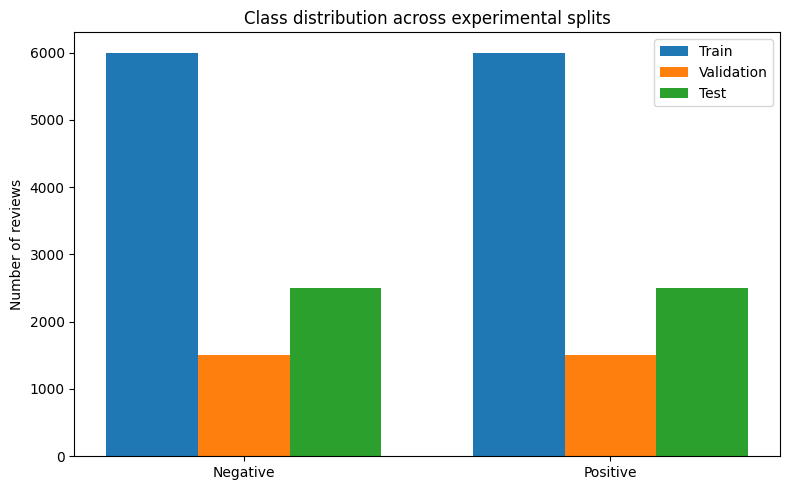

In [ ]:
combined = pd.concat([
    train_df.assign(split="Train"),
    validation_df.assign(split="Validation"),
    test_df.assign(split="Test"),
], ignore_index=True)
combined["sentiment"] = combined["label"].map({0: "Negative", 1: "Positive"})

label_summary = (
    combined.groupby(["split", "sentiment"])
    .size()
    .reset_index(name="count")
)
display(label_summary)

fig, ax = plt.subplots(figsize=(8, 5))
split_order = ["Train", "Validation", "Test"]
for index, split_name in enumerate(split_order):
    values = (
        label_summary[label_summary["split"] == split_name]
        .set_index("sentiment")
        .reindex(["Negative", "Positive"])["count"]
    )
    ax.bar(
        np.arange(2) + (index - 1) * 0.25,
        values,
        width=0.25,
        label=split_name,
    )

ax.set_xticks([0, 1], ["Negative", "Positive"])
ax.set_ylabel("Number of reviews")
ax.set_title("Class distribution across experimental splits")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

,count,mean,median,std,min,max
split,,,,,,
Test,5000,225.04,170.0,165.79,4,1157
Train,12000,232.94,173.5,174.79,10,2459
Validation,3000,233.26,172.0,175.96,26,1832


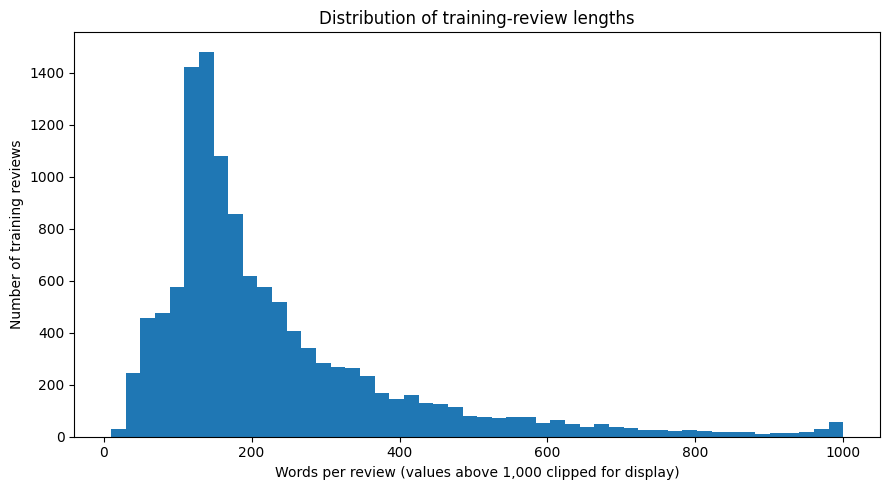

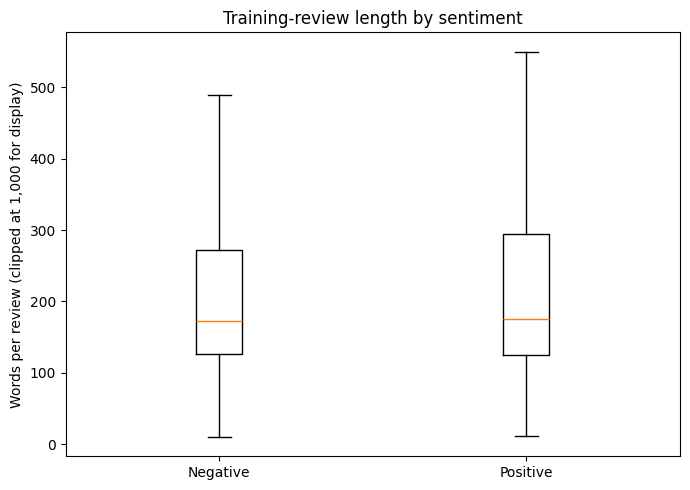

In [ ]:
for frame in (train_df, validation_df, test_df):
    frame["word_count"] = frame["text"].str.split().str.len()

length_summary = (
    pd.concat([
        train_df.assign(split="Train"),
        validation_df.assign(split="Validation"),
        test_df.assign(split="Test"),
    ])
    .groupby("split")["word_count"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(length_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train_df["word_count"].clip(upper=1_000), bins=50)
ax.set_xlabel("Words per review (values above 1,000 clipped for display)")
ax.set_ylabel("Number of training reviews")
ax.set_title("Distribution of training-review lengths")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# A compact sentiment-specific length comparison tests whether one class tends
# to contain systematically longer reviews, which could affect truncation.
negative_lengths = train_df.loc[train_df["label"] == 0, "word_count"]
positive_lengths = train_df.loc[train_df["label"] == 1, "word_count"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [negative_lengths.clip(upper=1_000), positive_lengths.clip(upper=1_000)],
    tick_labels=["Negative", "Positive"],
    showfliers=False,
)
ax.set_ylabel("Words per review (clipped at 1,000 for display)")
ax.set_title("Training-review length by sentiment")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_review_length_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

### EDA interpretation

The selected training, validation and test subsets are exactly balanced, so comparisons are not driven by class prevalence. Review lengths are strongly variable: the training median is 173.5 words, while the maximum is 2,459 words. This variation justifies explicit analysis of transformer truncation rather than assuming that one fixed input length represents all reviews.

# 4. Tuned classical comparison models

Two traditional text-classification models are included:

- **TF-IDF Logistic Regression:** a strong linear baseline with interpretable coefficients.
- **TF-IDF Multinomial Naïve Bayes:** a probabilistic baseline widely used for sparse text features.

Each model is placed inside a `Pipeline`, so TF-IDF is fitted independently within every cross-validation fold. Hyperparameters are selected using **mean stratified cross-validation F1**, because F1 balances precision and recall and is the primary model-selection metric.

The official test set remains untouched during this stage.

In [ ]:
def calculate_binary_metrics(
    true_labels: Sequence[int],
    predicted_labels: Sequence[int],
    positive_probabilities: Optional[Sequence[float]] = None,
) -> Dict[str, float]:
    """Calculate the required metrics consistently for every model."""
    result = {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "precision": precision_score(true_labels, predicted_labels, zero_division=0),
        "recall": recall_score(true_labels, predicted_labels, zero_division=0),
        "f1": f1_score(true_labels, predicted_labels, zero_division=0),
    }
    if positive_probabilities is not None and len(np.unique(true_labels)) == 2:
        result["roc_auc"] = roc_auc_score(true_labels, positive_probabilities)
    return result


def build_classical_searches(seed: int) -> Dict[str, GridSearchCV]:
    """
    Construct leakage-safe F1-tuned searches for both classical models.

    The parameter grids are intentionally bounded so the notebook remains
    reproducible and practical within the assignment's computational budget.
    """
    folds = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

    logistic_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            max_features=75_000,
        )),
        ("classifier", LogisticRegression(
            solver="liblinear",
            max_iter=1_000,
            random_state=seed,
        )),
    ])

    naive_bayes_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            max_features=75_000,
        )),
        ("classifier", MultinomialNB()),
    ])

    return {
        "TF-IDF + Logistic Regression": GridSearchCV(
            logistic_pipeline,
            {
                "tfidf__ngram_range": [(1, 1), (1, 2)],
                "classifier__C": [0.5, 1.0, 2.0],
            },
            scoring="f1",
            cv=folds,
            n_jobs=-1,
            verbose=1,
            refit=True,
            return_train_score=True,
        ),
        "TF-IDF + Multinomial Naive Bayes": GridSearchCV(
            naive_bayes_pipeline,
            {
                "tfidf__ngram_range": [(1, 1), (1, 2)],
                "classifier__alpha": [0.1, 0.5, 1.0],
            },
            scoring="f1",
            cv=folds,
            n_jobs=-1,
            verbose=1,
            refit=True,
            return_train_score=True,
        ),
    }


def evaluate_sklearn_model(model, texts, labels):
    """Return metrics, predictions, positive probabilities and inference time."""
    start = time.perf_counter()
    predictions = model.predict(texts)
    probabilities = model.predict_proba(texts)[:, 1]
    inference_seconds = time.perf_counter() - start

    return (
        calculate_binary_metrics(labels, predictions, probabilities),
        predictions,
        probabilities,
        inference_seconds,
    )

In [ ]:
classical_searches = build_classical_searches(CONFIG.seed)
classical_models = {}
classical_training_seconds = {}
classical_cv_tables = {}

for model_name, search in classical_searches.items():
    print("=" * 80)
    print(f"Tuning {model_name}")

    start = time.perf_counter()
    search.fit(train_df["text"], train_df["label"])
    training_seconds = time.perf_counter() - start

    classical_models[model_name] = search.best_estimator_
    classical_training_seconds[model_name] = training_seconds

    cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
    parameter_columns = [
        column for column in cv_results.columns
        if column.startswith("param_")
    ]
    cv_table = cv_results[
        ["rank_test_score", *parameter_columns,
         "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time"]
    ].rename(columns={
        "mean_test_score": "mean_cv_f1",
        "std_test_score": "std_cv_f1",
    })

    classical_cv_tables[model_name] = cv_table
    safe_name = re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")
    cv_table.to_csv(
        OUTPUT_DIR / f"{safe_name}_cross_validation.csv",
        index=False,
    )

    print("Best parameters:", search.best_params_)
    print(f"Best mean CV F1: {search.best_score_:.4f}")
    print(f"Training/search time: {training_seconds:.2f} seconds")
    display(cv_table.head(10))

Tuning TF-IDF + Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'classifier__C': 2.0, 'tfidf__ngram_range': (1, 2)}
Best mean CV F1: 0.8863
Training/search time: 166.29 seconds


,rank_test_score,param_classifier__C,param_tfidf__ngram_range,mean_train_score,mean_cv_f1,std_cv_f1,mean_fit_time
5,1,2.0,"(1, 2)",0.983309,0.886324,0.002113,11.979889
4,2,2.0,"(1, 1)",0.965971,0.884387,0.003886,3.256205
3,3,1.0,"(1, 2)",0.962942,0.882306,0.002927,11.450418
2,4,1.0,"(1, 1)",0.944071,0.879849,0.003944,3.417815
1,5,0.5,"(1, 2)",0.942262,0.875612,0.002274,18.734888
0,6,0.5,"(1, 1)",0.923415,0.872796,0.002916,5.052115


Tuning TF-IDF + Multinomial Naive Bayes
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'classifier__alpha': 0.1, 'tfidf__ngram_range': (1, 2)}
Best mean CV F1: 0.8762
Training/search time: 130.48 seconds


,rank_test_score,param_classifier__alpha,param_tfidf__ngram_range,mean_train_score,mean_cv_f1,std_cv_f1,mean_fit_time
1,1,0.1,"(1, 2)",0.978932,0.876162,0.005521,10.538502
3,2,0.5,"(1, 2)",0.963160,0.873684,0.004528,10.805948
5,3,1.0,"(1, 2)",0.952646,0.870599,0.004867,10.167429
2,4,0.5,"(1, 1)",0.937500,0.855397,0.003351,3.265751
4,5,1.0,"(1, 1)",0.924989,0.851598,0.003945,3.368666
0,6,0.1,"(1, 1)",0.955366,0.849743,0.004346,2.768178


In [ ]:
classical_validation_rows = []
classical_validation_outputs = {}

for model_name, model in classical_models.items():
    metrics, predictions, probabilities, inference_seconds = evaluate_sklearn_model(
        model,
        validation_df["text"],
        validation_df["label"],
    )

    classical_validation_outputs[model_name] = {
        "metrics": metrics,
        "predictions": predictions,
        "probabilities": probabilities,
        "inference_seconds": inference_seconds,
    }

    classical_validation_rows.append({
        "model": model_name,
        **metrics,
        "validation_inference_seconds": inference_seconds,
    })

classical_validation_table = (
    pd.DataFrame(classical_validation_rows)
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(classical_validation_table.round(4))
classical_validation_table.to_csv(
    OUTPUT_DIR / "classical_validation_comparison.csv",
    index=False,
)

best_classical_name = classical_validation_table.loc[0, "model"]
best_classical_model = classical_models[best_classical_name]

print(
    f"Best classical model selected by validation F1: {best_classical_name}"
)
print(
    "The test set remains unused until DistilBERT tuning and checkpoint "
    "selection are complete."
)

,model,accuracy,precision,recall,f1,roc_auc,validation_inference_seconds
0,TF-IDF + Logistic Regression,0.894,0.8878,0.9020,0.8948,0.9578,2.2846
1,TF-IDF + Multinomial Naive Bayes,0.883,0.8890,0.8753,0.8821,0.9492,2.3150


Best classical model selected by validation F1: TF-IDF + Logistic Regression
The test set remains unused until DistilBERT tuning and checkpoint selection are complete.


### Classical-model selection

Logistic Regression was the strongest classical model. It achieved mean cross-validation F1 of **0.8863** and validation F1 of **0.8948**, compared with **0.8762** and **0.8821** respectively for Multinomial Naïve Bayes. Logistic Regression was therefore selected as the principal classical comparison for paired significance testing.

In [ ]:
def strongest_logistic_features(
    fitted_pipeline: Pipeline,
    number: int = 20,
) -> pd.DataFrame:
    """
    Return the strongest positive and negative Logistic Regression features.

    Positive coefficients increase the log-odds of positive sentiment; negative
    coefficients decrease them. Coefficients are associations, not causal effects.
    """
    vectorizer = fitted_pipeline.named_steps["tfidf"]
    classifier = fitted_pipeline.named_steps["classifier"]

    feature_names = np.asarray(vectorizer.get_feature_names_out())
    coefficients = classifier.coef_[0]

    strongest_negative = np.argsort(coefficients)[:number]
    strongest_positive = np.argsort(coefficients)[-number:][::-1]

    return pd.DataFrame({
        "negative_feature": feature_names[strongest_negative],
        "negative_coefficient": coefficients[strongest_negative],
        "positive_feature": feature_names[strongest_positive],
        "positive_coefficient": coefficients[strongest_positive],
    })


logistic_model = classical_models["TF-IDF + Logistic Regression"]
logistic_feature_table = strongest_logistic_features(logistic_model)

display(logistic_feature_table)
logistic_feature_table.to_csv(
    OUTPUT_DIR / "logistic_regression_top_features.csv",
    index=False,
)

,negative_feature,negative_coefficient,positive_feature,positive_coefficient
0,bad,-8.326925,great,7.118730
1,worst,-6.523282,excellent,5.537662
2,awful,-5.287303,wonderful,3.907966
3,the worst,-5.268369,the best,3.893578
4,boring,-5.144531,love,3.707111
5,poor,-5.078495,perfect,3.696130
6,waste,-4.765783,amazing,3.654336
7,nothing,-4.422472,best,3.618901
8,terrible,-4.235623,very,3.495496
9,worse,-4.028439,fun,3.352932


# 5. DistilBERT architecture and suitability

DistilBERT is a distilled BERT encoder designed for downstream tasks such as sequence classification. Bidirectional self-attention can represent words using both left and right context. Compared with full BERT, DistilBERT offers a more practical accuracy–efficiency trade-off for limited Colab hardware.

### Implemented pipeline
`Review → WordPiece tokenizer → input IDs + attention mask → embeddings → 6 Transformer layers → first-token representation → pre-classifier + ReLU + dropout → 2 logits → cross-entropy loss`

The classification head is randomly initialised and the full network is fine-tuned.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG.model_name, use_fast=True)
model_config = AutoConfig.from_pretrained(CONFIG.model_name)

architecture = pd.DataFrame({
    'Property': [
        'Model', 'Vocabulary size', 'Maximum positions', 'Transformer layers',
        'Attention heads', 'Hidden dimension', 'Dropout', 'Output labels'
    ],
    'Value': [
        CONFIG.model_name,
        getattr(model_config, 'vocab_size', 'N/A'),
        getattr(model_config, 'max_position_embeddings', 'N/A'),
        getattr(model_config, 'n_layers', getattr(model_config, 'num_hidden_layers', 'N/A')),
        getattr(model_config, 'n_heads', getattr(model_config, 'num_attention_heads', 'N/A')),
        getattr(model_config, 'dim', getattr(model_config, 'hidden_size', 'N/A')),
        getattr(model_config, 'dropout', getattr(model_config, 'hidden_dropout_prob', 'N/A')),
        2,
    ]
})
display(architecture)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

,Property,Value
0,Model,distilbert/distilbert-base-uncased
1,Vocabulary size,30522
2,Maximum positions,512
3,Transformer layers,6
4,Attention heads,12
5,Hidden dimension,768
6,Dropout,0.1
7,Output labels,2


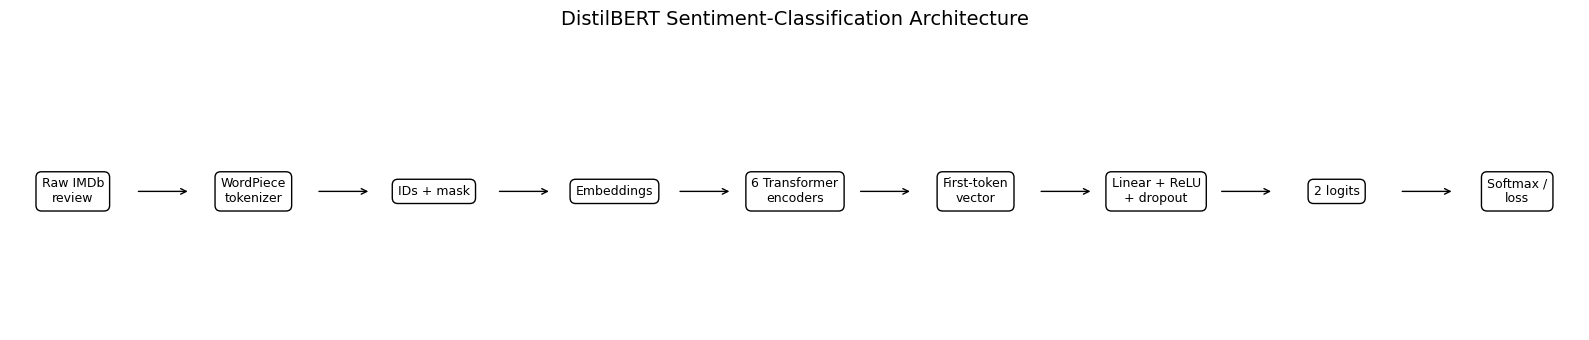

In [ ]:
def plot_architecture(save_path: Path) -> None:
    """Draw the exact classification pipeline used in this notebook."""
    stages = [
        'Raw IMDb\nreview', 'WordPiece\ntokenizer', 'IDs + mask', 'Embeddings',
        '6 Transformer\nencoders', 'First-token\nvector',
        'Linear + ReLU\n+ dropout', '2 logits', 'Softmax /\nloss'
    ]
    fig, ax = plt.subplots(figsize=(16, 3.5))
    ax.axis('off')
    positions = np.linspace(0.04, 0.96, len(stages))
    for index, (x, label) in enumerate(zip(positions, stages)):
        ax.text(x, 0.5, label, ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='black'),
                transform=ax.transAxes)
        if index < len(stages) - 1:
            ax.annotate('', xy=(positions[index + 1] - 0.04, 0.5),
                        xytext=(x + 0.04, 0.5),
                        arrowprops=dict(arrowstyle='->'), xycoords=ax.transAxes)
    ax.set_title('DistilBERT Sentiment-Classification Architecture', fontsize=14, pad=20)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_architecture(OUTPUT_DIR / '04_distilbert_architecture.png')

## 5.1 Tokenisation and truncation

Dynamic padding pads each batch only to its longest sequence, reducing unnecessary computation. Reviews longer than `max_length` are truncated; the notebook measures how often this occurs so it can be discussed as a limitation.

In [ ]:
example = train_df.loc[0, 'text']
encoded = tokenizer(example, truncation=True, max_length=CONFIG.max_length)
print(example[:350])
print()
print('First 30 tokens:', tokenizer.convert_ids_to_tokens(encoded['input_ids'][:30]))
print('First 30 input IDs:', encoded['input_ids'][:30])
print('First 30 attention-mask values:', encoded['attention_mask'][:30])

Sean, you know I think that you are absolutely the greatest actor in the world, but I can't commend you for this. Comedy just isn't your strong suit. However, it wasn't all your fault. Some of the stuff was just too hard to understand. Alfred Lynch did a decent job, but you gotta wonder where the lines came from from the beginning. Once again, Sean

First 30 tokens: ['[CLS]', 'sean', ',', 'you', 'know', 'i', 'think', 'that', 'you', 'are', 'absolutely', 'the', 'greatest', 'actor', 'in', 'the', 'world', ',', 'but', 'i', 'can', "'", 't', 'com', '##men', '##d', 'you', 'for', 'this', '.']
First 30 input IDs: [101, 5977, 1010, 2017, 2113, 1045, 2228, 2008, 2017, 2024, 7078, 1996, 4602, 3364, 1999, 1996, 2088, 1010, 2021, 1045, 2064, 1005, 1056, 4012, 3549, 2094, 2017, 2005, 2023, 1012]
First 30 attention-mask values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Token lengths:   0%|          | 0/20 [00:00<?, ?it/s]

,Statistic,Value
0,Median,218.00
1,Mean,289.31
2,95th percentile,742.05
3,Maximum,1499.00
4,Percent > 256,39.82


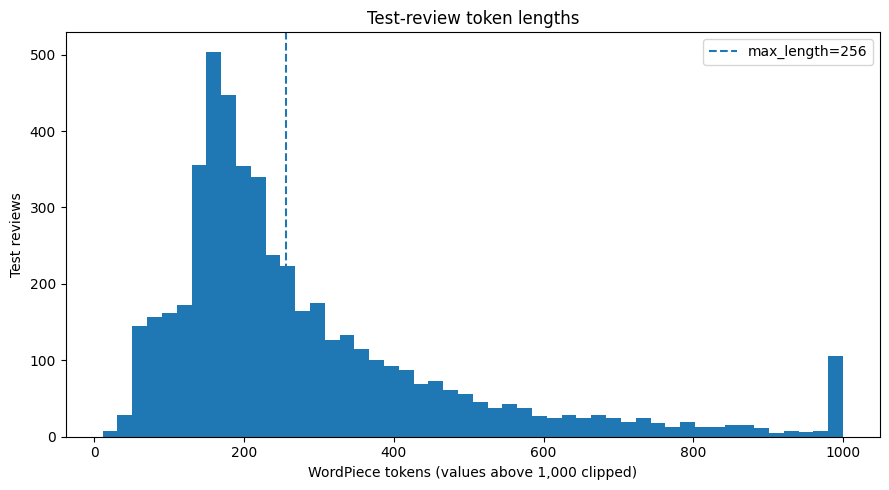

In [ ]:
def token_lengths(texts: Sequence[str], tokenizer, batch_size: int = 256) -> np.ndarray:
    """Calculate untruncated token lengths in bounded batches."""
    lengths: List[int] = []
    for start in tqdm(range(0, len(texts), batch_size), desc='Token lengths'):
        batch = list(texts[start:start + batch_size])
        output = tokenizer(
            batch,
            truncation=False,
            padding=False,
            return_length=True,
            verbose=False,
        )
        lengths.extend(output['length'])
    return np.asarray(lengths)

test_token_lengths = token_lengths(test_df['text'].tolist(), tokenizer)
truncation_rate = float(np.mean(test_token_lengths > CONFIG.max_length))
display(pd.DataFrame({
    'Statistic': ['Median', 'Mean', '95th percentile', 'Maximum', f'Percent > {CONFIG.max_length}'],
    'Value': [
        np.median(test_token_lengths), np.mean(test_token_lengths),
        np.percentile(test_token_lengths, 95), np.max(test_token_lengths),
        truncation_rate * 100,
    ]
}).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(np.clip(test_token_lengths, 0, 1000), bins=50)
ax.axvline(CONFIG.max_length, linestyle='--', label=f'max_length={CONFIG.max_length}')
ax.set_xlabel('WordPiece tokens (values above 1,000 clipped)')
ax.set_ylabel('Test reviews')
ax.set_title('Test-review token lengths')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_token_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Reusable PyTorch data pipeline

The custom dataset tokenises each split once. `DataCollatorWithPadding` then performs dynamic padding and creates PyTorch tensors. This is more efficient than re-tokenising every review during every epoch.

In [ ]:
class EncodedTextDataset(Dataset):
    """Pre-tokenised text dataset for dynamic batch padding."""
    def __init__(self, texts, labels, tokenizer, max_length: int):
        if len(texts) != len(labels):
            raise ValueError('texts and labels must have equal length.')
        self.encodings = tokenizer(
            list(texts), truncation=True, max_length=max_length, padding=False
        )
        self.labels = [int(value) for value in labels]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> Dict[str, object]:
        item = {key: values[index] for key, values in self.encodings.items()}
        item['labels'] = self.labels[index]
        return item


def create_dataloader(frame, tokenizer, max_length: int, batch_size: int, shuffle: bool) -> DataLoader:
    """Create a deterministic dynamically padded DataLoader."""
    dataset = EncodedTextDataset(frame['text'], frame['label'], tokenizer, max_length)
    collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if DEVICE.type == 'cuda' else None,
        return_tensors='pt',
    )
    generator = torch.Generator().manual_seed(CONFIG.seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collator,
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        generator=generator if shuffle else None,
    )

# 7. Custom DistilBERT fine-tuning loop

The assignment explicitly requests a training loop, optimizer and loss. Therefore, training is implemented directly in PyTorch rather than hidden inside Hugging Face `Trainer`.

- **Cross-entropy loss:** returned by the model when integer labels are supplied.
- **AdamW:** adaptive optimisation with decoupled weight decay.
- **Linear warm-up/decay:** stabilises early updates and reduces the learning rate over time.
- **Gradient clipping:** limits unstable gradients.
- **Mixed precision:** used only on CUDA for speed and memory efficiency.
- **Early stopping/checkpointing:** based only on validation F1.

In [ ]:
def build_transformer_model(model_name: str):
    """Load DistilBERT with a two-class classification head."""
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
        label2id={'NEGATIVE': 0, 'POSITIVE': 1},
    )


def count_parameters(model) -> Dict[str, int]:
    """Count total and trainable network parameters."""
    return {
        'total_parameters': sum(parameter.numel() for parameter in model.parameters()),
        'trainable_parameters': sum(
            parameter.numel() for parameter in model.parameters() if parameter.requires_grad
        ),
    }


def make_grad_scaler(enabled: bool):
    """Support both recent and older PyTorch GradScaler signatures."""
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        try:
            return torch.amp.GradScaler('cuda', enabled=enabled)
        except TypeError:
            return torch.amp.GradScaler(enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)


def move_batch(batch, device):
    return {key: value.to(device) for key, value in batch.items()}

In [ ]:
def train_one_epoch(model, dataloader, optimizer, scheduler, scaler, config):
    """Train one epoch and return loss plus classification metrics."""
    model.train()
    total_loss = 0.0
    labels_all, predictions_all = [], []
    use_amp = bool(config.use_amp and DEVICE.type == 'cuda')

    for batch in tqdm(dataloader, desc='Training', leave=False):
        batch = move_batch(batch, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        context = torch.autocast('cuda', dtype=torch.float16) if use_amp else nullcontext()
        with context:
            output = model(**batch)
            loss = output.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), config.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        predictions = output.logits.detach().argmax(dim=-1)
        total_loss += loss.item() * batch['labels'].size(0)
        labels_all.extend(batch['labels'].detach().cpu().tolist())
        predictions_all.extend(predictions.cpu().tolist())

    metrics = calculate_binary_metrics(labels_all, predictions_all)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    return metrics


@torch.no_grad()
def evaluate_transformer(model, dataloader):
    """Evaluate without gradient updates and return all report-ready outputs."""
    model.eval()
    total_loss = 0.0
    labels_all, predictions_all, probabilities_all = [], [], []
    start = time.perf_counter()

    for batch in tqdm(dataloader, desc='Evaluating', leave=False):
        batch = move_batch(batch, DEVICE)
        output = model(**batch)
        probabilities = torch.softmax(output.logits, dim=-1)
        predictions = probabilities.argmax(dim=-1)
        total_loss += output.loss.item() * batch['labels'].size(0)
        labels_all.extend(batch['labels'].cpu().tolist())
        predictions_all.extend(predictions.cpu().tolist())
        probabilities_all.extend(probabilities[:, 1].cpu().tolist())

    seconds = time.perf_counter() - start
    labels_array = np.asarray(labels_all)
    predictions_array = np.asarray(predictions_all)
    probabilities_array = np.asarray(probabilities_all)
    metrics = calculate_binary_metrics(labels_array, predictions_array, probabilities_array)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    return metrics, labels_array, predictions_array, probabilities_array, seconds

In [ ]:
def fit_transformer(config, train_frame, validation_frame, checkpoint_name: str):
    """Fine-tune and restore the checkpoint with the highest validation F1."""
    train_loader = create_dataloader(
        train_frame, tokenizer, config.max_length, config.batch_size, True
    )
    validation_loader = create_dataloader(
        validation_frame, tokenizer, config.max_length, config.batch_size, False
    )
    model = build_transformer_model(config.model_name).to(DEVICE)
    parameter_counts = count_parameters(model)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    total_steps = len(train_loader) * config.epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * config.warmup_ratio),
        num_training_steps=total_steps,
    )
    use_amp = bool(config.use_amp and DEVICE.type == 'cuda')
    scaler = make_grad_scaler(use_amp)
    checkpoint_path = OUTPUT_DIR / checkpoint_name

    best_f1 = -np.inf
    no_improvement = 0
    history_rows = []
    start = time.perf_counter()

    for epoch in range(config.epochs):
        print(f'\nEpoch {epoch + 1}/{config.epochs}')
        train_metrics = train_one_epoch(
            model, train_loader, optimizer, scheduler, scaler, config
        )
        validation_metrics, _, _, _, validation_seconds = evaluate_transformer(
            model, validation_loader
        )
        row = {
            'epoch': epoch + 1,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'validation_loss': validation_metrics['loss'],
            'validation_accuracy': validation_metrics['accuracy'],
            'validation_precision': validation_metrics['precision'],
            'validation_recall': validation_metrics['recall'],
            'validation_f1': validation_metrics['f1'],
            'validation_roc_auc': validation_metrics['roc_auc'],
            'validation_seconds': validation_seconds,
            'learning_rate_after_epoch': scheduler.get_last_lr()[0],
        }
        history_rows.append(row)
        row_display = pd.DataFrame([row]).round(4)
        row_display['learning_rate_after_epoch'] = (
            pd.DataFrame([row])['learning_rate_after_epoch']
            .map(lambda value: f'{value:.2e}')
        )
        display(row_display)

        if validation_metrics['f1'] > best_f1:
            best_f1 = validation_metrics['f1']
            no_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Saved best checkpoint: validation F1={best_f1:.4f}')
        else:
            no_improvement += 1
            if no_improvement >= config.early_stopping_patience:
                print('Early stopping activated.')
                break

    training_seconds = time.perf_counter() - start
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model, pd.DataFrame(history_rows), training_seconds, parameter_counts

# 8. Validation-only transformer hyperparameter search

Three bounded trials compare learning rate and input length on smaller balanced subsets. This is a defensible compromise between systematic tuning and limited GPU resources. The test set is not used for selection.

In [ ]:
def stratified_frame_sample(frame: pd.DataFrame, size: int, seed: int) -> pd.DataFrame:
    """Return an exactly balanced dataframe sample."""
    size = min(size, len(frame))
    size -= size % 2
    parts = [
        frame[frame['label'] == label].sample(size // 2, random_state=seed + label)
        for label in (0, 1)
    ]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

tuning_train_df = stratified_frame_sample(train_df, CONFIG.tuning_train_size, CONFIG.seed + 10)
tuning_validation_df = stratified_frame_sample(validation_df, CONFIG.tuning_validation_size, CONFIG.seed + 20)

tuning_candidates = [
    {'learning_rate': 2e-5, 'max_length': 128, 'batch_size': 16},
    {'learning_rate': 3e-5, 'max_length': 128, 'batch_size': 16},
    {'learning_rate': 2e-5, 'max_length': 256, 'batch_size': 16},
]
display(pd.DataFrame(tuning_candidates))

,learning_rate,max_length,batch_size
0,0.00002,128,16
1,0.00003,128,16
2,0.00002,256,16


In [ ]:
def run_tuning(candidates) -> pd.DataFrame:
    """Run bounded one-epoch trials and rank by validation F1 then ROC-AUC."""
    rows = []
    for trial, candidate in enumerate(candidates, start=1):
        print('=' * 70)
        print('Trial', trial, candidate)
        trial_config = replace(
            CONFIG,
            learning_rate=float(candidate['learning_rate']),
            max_length=int(candidate['max_length']),
            batch_size=int(candidate['batch_size']),
            epochs=CONFIG.tuning_epochs,
            early_stopping_patience=CONFIG.tuning_epochs + 1,
        )
        trial_model, history, seconds, _ = fit_transformer(
            trial_config, tuning_train_df, tuning_validation_df,
            f'tuning_trial_{trial}.pt'
        )
        best = history.loc[history['validation_f1'].idxmax()]
        rows.append({
            'trial': trial,
            **candidate,
            'validation_loss': best['validation_loss'],
            'validation_accuracy': best['validation_accuracy'],
            'validation_precision': best['validation_precision'],
            'validation_recall': best['validation_recall'],
            'validation_f1': best['validation_f1'],
            'validation_roc_auc': best['validation_roc_auc'],
            'trial_seconds': seconds,
        })
        del trial_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return pd.DataFrame(rows).sort_values(
        ['validation_f1', 'validation_roc_auc'], ascending=False
    ).reset_index(drop=True)

if CONFIG.run_transformer_tuning:
    tuning_results = run_tuning(tuning_candidates)
    best_trial = tuning_results.iloc[0]
    FINAL_CONFIG = replace(
        CONFIG,
        learning_rate=float(best_trial['learning_rate']),
        max_length=int(best_trial['max_length']),
        batch_size=int(best_trial['batch_size']),
    )
else:
    tuning_results = pd.DataFrame([{'note': 'Tuning disabled'}])
    FINAL_CONFIG = CONFIG

display(tuning_results)
tuning_results.to_csv(OUTPUT_DIR / 'transformer_tuning.csv', index=False)
display(pd.DataFrame([{
    'learning_rate': FINAL_CONFIG.learning_rate,
    'max_length': FINAL_CONFIG.max_length,
    'batch_size': FINAL_CONFIG.batch_size,
    'epochs': FINAL_CONFIG.epochs,
    'weight_decay': FINAL_CONFIG.weight_decay,
    'warmup_ratio': FINAL_CONFIG.warmup_ratio,
}]))

final_truncation_rate = float(np.mean(test_token_lengths > FINAL_CONFIG.max_length))
print(
    f'{final_truncation_rate * 100:.2f}% of the selected test reviews exceed '
    f'the final max_length={FINAL_CONFIG.max_length} tokens.'
)

Trial 1 {'learning_rate': 2e-05, 'max_length': 128, 'batch_size': 16}


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

,epoch,train_loss,train_accuracy,train_f1,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_seconds,learning_rate_after_epoch
0,1,0.439,0.7857,0.7842,0.3138,0.865,0.8614,0.87,0.8657,0.9465,6.8567,0.00e+00


Saved best checkpoint: validation F1=0.8657


,trial,learning_rate,max_length,batch_size,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,trial_seconds
0,3,0.00002,256,16,0.313781,0.865,0.861386,0.870,0.865672,0.946524,30.137665
1,1,0.00002,128,16,0.389840,0.816,0.825103,0.802,0.813387,0.912192,20.015446
2,2,0.00003,128,16,0.386990,0.820,0.850877,0.776,0.811715,0.914676,19.149845


,learning_rate,max_length,batch_size,epochs,weight_decay,warmup_ratio
0,0.00002,256,16,3,0.01,0.1


39.82% of the selected test reviews exceed the final max_length=256 tokens.


### Hyperparameter-selection result

The strongest bounded trial used a learning rate of **2 × 10⁻⁵** and maximum sequence length of **256**, achieving validation F1 of **0.8657** on the tuning subset. Both 128-token configurations performed substantially worse, indicating that retaining more review context was more influential than increasing the learning rate within the tested range.

# 9. Final model training and learning curves

The selected validation configuration is trained on the main training split. The best validation-F1 checkpoint is restored before test evaluation.

In [ ]:
final_model, training_history, transformer_training_seconds, parameter_counts = fit_transformer(
    FINAL_CONFIG, train_df, validation_df, 'best_distilbert_state.pt'
)
history_display = training_history.round(4)
history_display['learning_rate_after_epoch'] = (
    training_history['learning_rate_after_epoch']
    .map(lambda value: f'{value:.2e}')
)
display(history_display)
training_history.to_csv(OUTPUT_DIR / 'distilbert_training_history.csv', index=False)
display(pd.DataFrame([parameter_counts]))
print(f'Final training time: {transformer_training_seconds:.2f} seconds')

model_directory = OUTPUT_DIR / 'best_distilbert_model'
final_model.save_pretrained(model_directory)
tokenizer.save_pretrained(model_directory)
with open(OUTPUT_DIR / 'final_config.json', 'w', encoding='utf-8') as file:
    json.dump(asdict(FINAL_CONFIG), file, indent=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


Training:   0%|          | 0/750 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/188 [00:00<?, ?it/s]

...

Saved best checkpoint: validation F1=0.9060


,epoch,train_loss,train_accuracy,train_f1,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_seconds,learning_rate_after_epoch
0,1,0.3605,0.8395,0.8430,0.2663,0.8883,0.8554,0.9347,0.8933,0.9631,22.0128,1.48e-05
1,2,0.1948,0.9323,0.9325,0.2671,0.9013,0.9024,0.9000,0.9012,0.9647,22.2788,7.41e-06
2,3,0.1193,0.9640,0.9641,0.3424,0.9070,0.9162,0.8960,0.9060,0.9649,22.2652,0.00e+00


,total_parameters,trainable_parameters
0,66955010,66955010


Final training time: 363.27 seconds


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

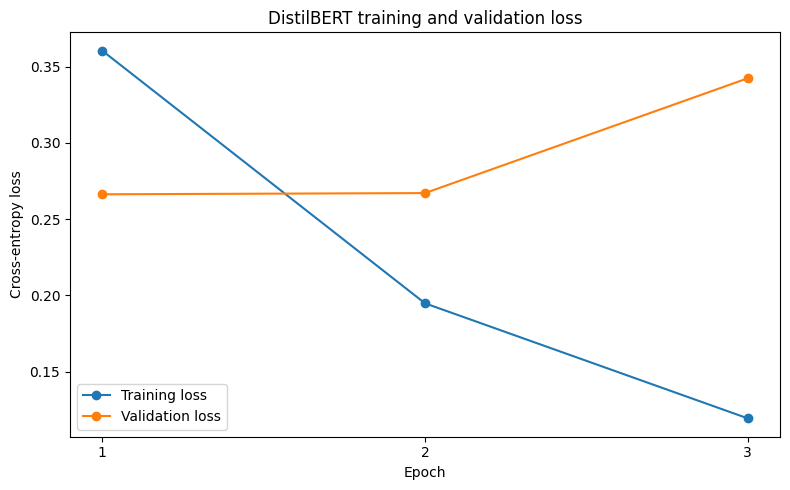

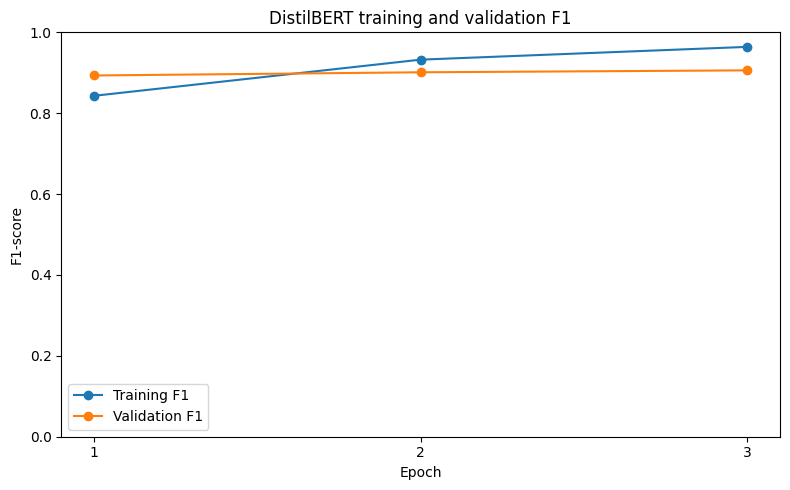

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(training_history['epoch'], training_history['train_loss'], marker='o', label='Training loss')
ax.plot(training_history['epoch'], training_history['validation_loss'], marker='o', label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('DistilBERT training and validation loss')
ax.set_xticks(training_history['epoch'])
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '06_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(training_history['epoch'], training_history['train_f1'], marker='o', label='Training F1')
ax.plot(training_history['epoch'], training_history['validation_f1'], marker='o', label='Validation F1')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
ax.set_title('DistilBERT training and validation F1')
ax.set_xticks(training_history['epoch'])
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '07_training_f1.png', dpi=300, bbox_inches='tight')
plt.show()

### Training behaviour

Training F1 increased from **0.8430** to **0.9641**, while validation F1 increased from **0.8933** to **0.9060**. Validation loss rose from **0.2663** to **0.3424** by the third epoch, producing a widening training–validation gap. This indicates increasing overfitting even though validation F1 continued to improve. Checkpoint selection by validation F1 limited the model-selection decision to held-out development data.

# 10. Final test evaluation

Only after the classical searches, DistilBERT tuning and validation-based checkpoint selection are complete is the cleaned test set evaluated.

All models use the same test reviews. The assignment's required metrics—accuracy, precision, recall and F1—are reported for each model. ROC-AUC is included as an additional threshold-independent measure.

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]

TF-IDF + Logistic Regression — test metrics


,accuracy,precision,recall,f1,roc_auc
0,0.8926,0.8915,0.894,0.8928,0.9583


              precision    recall  f1-score   support

    Negative     0.8937    0.8912    0.8924      2500
    Positive     0.8915    0.8940    0.8928      2500

    accuracy                         0.8926      5000
   macro avg     0.8926    0.8926    0.8926      5000
weighted avg     0.8926    0.8926    0.8926      5000

TF-IDF + Multinomial Naive Bayes — test metrics


,accuracy,precision,recall,f1,roc_auc
0,0.8714,0.8883,0.8496,0.8685,0.9424


              precision    recall  f1-score   support

    Negative     0.8559    0.8932    0.8741      2500
    Positive     0.8883    0.8496    0.8685      2500

    accuracy                         0.8714      5000
   macro avg     0.8721    0.8714    0.8713      5000
weighted avg     0.8721    0.8714    0.8713      5000

Fine-tuned DistilBERT — test metrics


,accuracy,precision,recall,f1,roc_auc,loss
0,0.9064,0.9093,0.9028,0.9061,0.9689,0.3287


              precision    recall  f1-score   support

    Negative     0.9035    0.9100    0.9067      2500
    Positive     0.9093    0.9028    0.9061      2500

    accuracy                         0.9064      5000
   macro avg     0.9064    0.9064    0.9064      5000
weighted avg     0.9064    0.9064    0.9064      5000



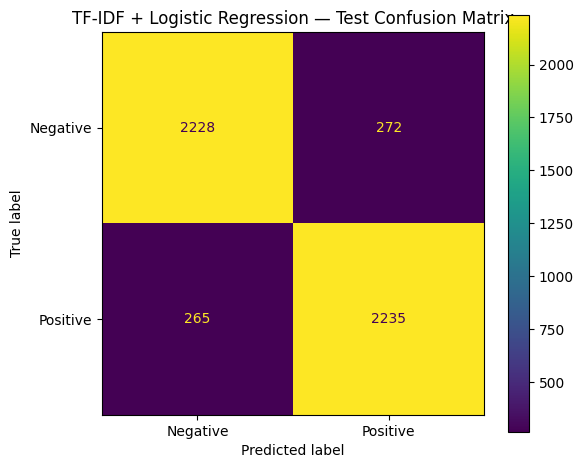

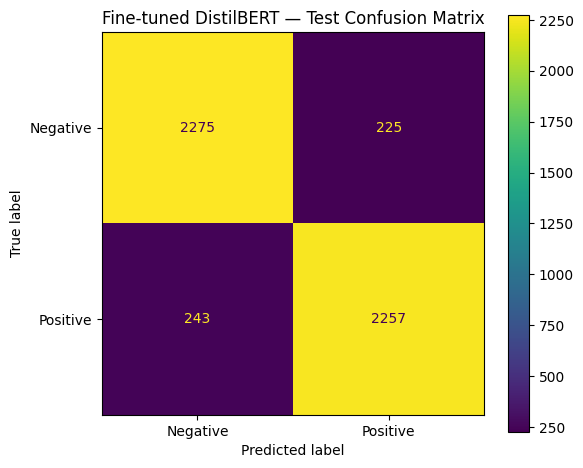

In [ ]:
test_loader = create_dataloader(
    test_df,
    tokenizer,
    FINAL_CONFIG.max_length,
    FINAL_CONFIG.batch_size,
    False,
)

(
    transformer_test_metrics,
    transformer_test_labels,
    transformer_test_predictions,
    transformer_test_probabilities,
    transformer_test_inference_seconds,
) = evaluate_transformer(final_model, test_loader)

test_outputs = {}
test_result_rows = []

for model_name, model in classical_models.items():
    metrics, predictions, probabilities, inference_seconds = evaluate_sklearn_model(
        model,
        test_df["text"],
        test_df["label"],
    )

    test_outputs[model_name] = {
        "metrics": metrics,
        "predictions": predictions,
        "probabilities": probabilities,
        "inference_seconds": inference_seconds,
    }

    test_result_rows.append({
        "model": model_name,
        **metrics,
        "training_seconds": classical_training_seconds[model_name],
        "test_inference_seconds": inference_seconds,
        "trainable_parameters": np.nan,
    })

test_outputs["Fine-tuned DistilBERT"] = {
    "metrics": transformer_test_metrics,
    "predictions": transformer_test_predictions,
    "probabilities": transformer_test_probabilities,
    "inference_seconds": transformer_test_inference_seconds,
}

test_result_rows.append({
    "model": "Fine-tuned DistilBERT",
    **{
        key: value
        for key, value in transformer_test_metrics.items()
        if key != "loss"
    },
    "training_seconds": transformer_training_seconds,
    "test_inference_seconds": transformer_test_inference_seconds,
    "trainable_parameters": parameter_counts["trainable_parameters"],
})

for model_name, output in test_outputs.items():
    print("=" * 80)
    print(f"{model_name} — test metrics")
    display(pd.DataFrame([output["metrics"]]).round(4))
    print(classification_report(
        test_df["label"],
        output["predictions"],
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0,
    ))

for model_name in [best_classical_name, "Fine-tuned DistilBERT"]:
    safe_name = re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        test_df["label"],
        test_outputs[model_name]["predictions"],
        display_labels=["Negative", "Positive"],
        values_format="d",
        ax=ax,
    )
    ax.set_title(f"{model_name} — Test Confusion Matrix")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

# 11. Model comparison and automatic winner identification

The final comparison ranks all models by test F1 while retaining every required metric. It also identifies the best-performing model for accuracy, precision, recall, F1 and ROC-AUC separately.

F1 is the primary comparison metric because it balances false-positive and false-negative performance and was also used during model selection. Test results are used only for final reporting, not for further tuning.

,model,accuracy,precision,recall,f1,roc_auc,training_seconds,test_inference_seconds,trainable_parameters
0,Fine-tuned DistilBERT,0.9064,0.9093,0.9028,0.9061,0.9689,363.2697,37.2193,66955010.0
1,TF-IDF + Logistic Regression,0.8926,0.8915,0.8940,0.8928,0.9583,166.2901,3.6893,NaN
2,TF-IDF + Multinomial Naive Bayes,0.8714,0.8883,0.8496,0.8685,0.9424,130.4839,5.1027,NaN


,metric,best_model,best_score
0,accuracy,Fine-tuned DistilBERT,0.9064
1,precision,Fine-tuned DistilBERT,0.9093
2,recall,Fine-tuned DistilBERT,0.9028
3,f1,Fine-tuned DistilBERT,0.9061
4,roc_auc,Fine-tuned DistilBERT,0.9689


Best overall model by test F1: Fine-tuned DistilBERT


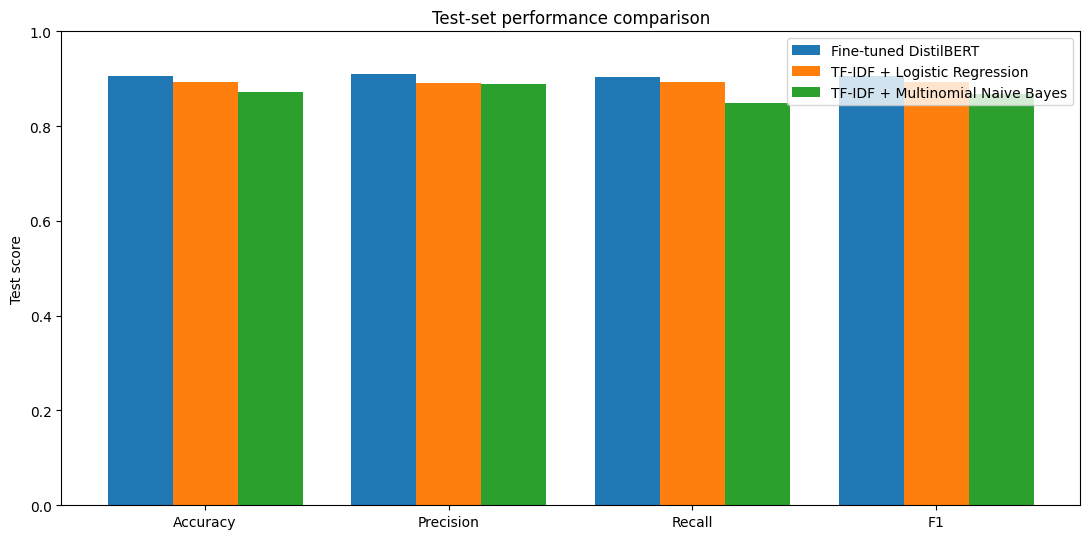

In [ ]:
comparison = (
    pd.DataFrame(test_result_rows)
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(comparison.round(4))
comparison.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False,
)

metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
winner_rows = []

for metric_name in metric_names:
    winner_index = comparison[metric_name].idxmax()
    winner_rows.append({
        "metric": metric_name,
        "best_model": comparison.loc[winner_index, "model"],
        "best_score": comparison.loc[winner_index, metric_name],
    })

metric_winners = pd.DataFrame(winner_rows)
display(metric_winners.round(4))
metric_winners.to_csv(
    OUTPUT_DIR / "best_model_by_metric.csv",
    index=False,
)

best_overall_model = comparison.loc[0, "model"]
print(f"Best overall model by test F1: {best_overall_model}")

metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
positions = np.arange(len(metrics_to_plot))
number_of_models = len(comparison)
width = 0.8 / number_of_models

fig, ax = plt.subplots(figsize=(11, 5.5))
for model_index, model_name in enumerate(comparison["model"]):
    values = comparison.loc[
        comparison["model"] == model_name,
        metrics_to_plot,
    ].iloc[0].values

    offset = (model_index - (number_of_models - 1) / 2) * width
    ax.bar(
        positions + offset,
        values,
        width=width,
        label=model_name,
    )

ax.set_xticks(positions, [metric.title() for metric in metrics_to_plot])
ax.set_ylim(0, 1)
ax.set_ylabel("Test score")
ax.set_title("Test-set performance comparison")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "model_metric_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

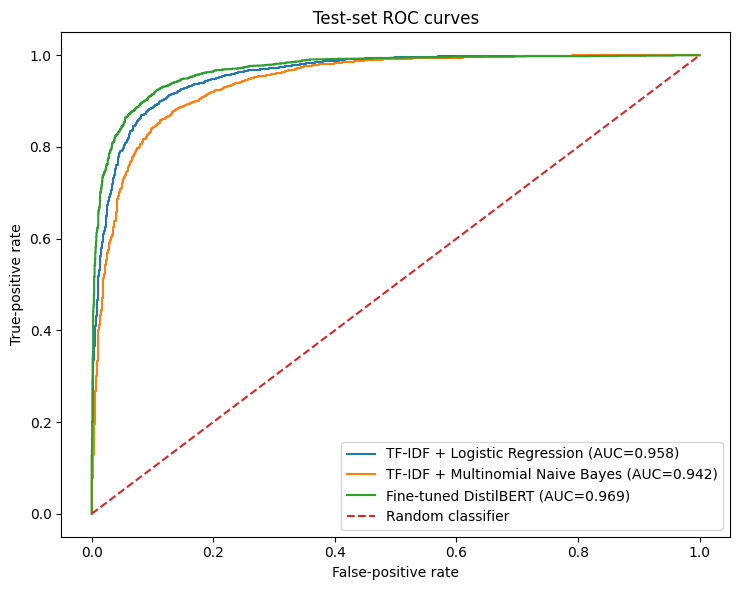

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))

for model_name, output in test_outputs.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(
        test_df["label"],
        output["probabilities"],
    )
    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{model_name} "
            f"(AUC={output['metrics']['roc_auc']:.3f})"
        ),
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("Test-set ROC curves")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Test-performance interpretation

Fine-tuned DistilBERT was the strongest model on every reported test metric: accuracy **0.9064**, precision **0.9093**, recall **0.9028**, F1 **0.9061** and ROC-AUC **0.9689**. Logistic Regression was the strongest baseline with F1 **0.8928**, while Multinomial Naïve Bayes achieved F1 **0.8685**.

DistilBERT improved F1 by 0.0133 over Logistic Regression but required greater computation. Final DistilBERT training required 363.27 seconds and test inference required 37.22 seconds, compared with 166.29 seconds for the Logistic Regression grid search and 3.69 seconds for its test inference. The transformer tuning trials required a further 69.30 seconds.

# 12. Uncertainty and paired significance

Bootstrap intervals show uncertainty around accuracy and F1. McNemar's exact test is appropriate because both models make predictions on the same test observations. Interpret `p < 0.05` as evidence of different error rates, not proof of universal superiority.

In [ ]:
def bootstrap_interval(
    true_labels,
    predictions,
    metric_function,
    iterations: int,
    seed: int,
):
    """Calculate a non-parametric percentile bootstrap 95% interval."""
    true_array = np.asarray(true_labels)
    prediction_array = np.asarray(predictions)
    rng = np.random.default_rng(seed)
    scores = np.empty(iterations)

    for iteration in range(iterations):
        sampled_indices = rng.integers(
            0,
            len(true_array),
            size=len(true_array),
        )
        scores[iteration] = metric_function(
            true_array[sampled_indices],
            prediction_array[sampled_indices],
        )

    return {
        "estimate": metric_function(true_array, prediction_array),
        "ci_lower_95": np.percentile(scores, 2.5),
        "ci_upper_95": np.percentile(scores, 97.5),
    }


confidence_rows = []

for model_name, output in test_outputs.items():
    for metric_name, metric_function in [
        ("Accuracy", accuracy_score),
        (
            "F1",
            lambda true_values, predicted_values: f1_score(
                true_values,
                predicted_values,
                zero_division=0,
            ),
        ),
    ]:
        confidence_rows.append({
            "model": model_name,
            "metric": metric_name,
            **bootstrap_interval(
                test_df["label"],
                output["predictions"],
                metric_function,
                CONFIG.bootstrap_iterations,
                CONFIG.seed,
            ),
        })

confidence_intervals = pd.DataFrame(confidence_rows)
display(confidence_intervals.round(4))
confidence_intervals.to_csv(
    OUTPUT_DIR / "bootstrap_confidence_intervals.csv",
    index=False,
)

,model,metric,estimate,ci_lower_95,ci_upper_95
0,TF-IDF + Logistic Regression,Accuracy,0.8926,0.8837,0.9015
1,TF-IDF + Logistic Regression,F1,0.8928,0.8834,0.9015
2,TF-IDF + Multinomial Naive Bayes,Accuracy,0.8714,0.8614,0.8810
3,TF-IDF + Multinomial Naive Bayes,F1,0.8685,0.8583,0.8788
4,Fine-tuned DistilBERT,Accuracy,0.9064,0.8985,0.9151
5,Fine-tuned DistilBERT,F1,0.9061,0.8983,0.9149


In [ ]:
def mcnemar_exact(
    true_labels,
    comparison_predictions,
    transformer_predictions,
):
    """
    Perform an exact paired McNemar test on discordant predictions.

    The test is applied between the validation-selected best classical model
    and DistilBERT because both predict the same test examples.
    """
    true_array = np.asarray(true_labels)
    comparison_correct = np.asarray(comparison_predictions) == true_array
    transformer_correct = np.asarray(transformer_predictions) == true_array

    comparison_only = int(
        np.sum(comparison_correct & ~transformer_correct)
    )
    transformer_only = int(
        np.sum(~comparison_correct & transformer_correct)
    )
    discordant_total = comparison_only + transformer_only

    p_value = (
        1.0
        if discordant_total == 0
        else binomtest(
            comparison_only,
            discordant_total,
            0.5,
        ).pvalue
    )

    return {
        "comparison_model": best_classical_name,
        "comparison_correct_transformer_wrong": comparison_only,
        "comparison_wrong_transformer_correct": transformer_only,
        "discordant_total": discordant_total,
        "exact_p_value": p_value,
    }


mcnemar_result = mcnemar_exact(
    test_df["label"],
    test_outputs[best_classical_name]["predictions"],
    transformer_test_predictions,
)

display(pd.DataFrame([mcnemar_result]).round(6))

,comparison_model,comparison_correct_transformer_wrong,comparison_wrong_transformer_correct,discordant_total,exact_p_value
0,TF-IDF + Logistic Regression,247,316,563,0.004119


### Uncertainty and paired comparison

The bootstrap 95% F1 interval was **0.8983–0.9149** for DistilBERT and **0.8834–0.9015** for Logistic Regression. In the paired error comparison, DistilBERT alone was correct on 316 reviews, whereas Logistic Regression alone was correct on 247. McNemar’s exact test produced **p = 0.0041**, providing evidence that their error rates differ on this test sample. This does not establish universal superiority beyond the evaluated dataset and experimental design.

# 13. Error and truncation analysis

Inspect high-confidence false positives and false negatives. Discuss sarcasm, mixed sentiment, negation, unusual vocabulary, plot summaries, rating conflicts, long inputs and missing context. Error examples should support an argument, not be included only as decoration.

In [ ]:
error_frame = test_df[["text", "label", "word_count"]].copy()
error_frame["best_classical_model"] = best_classical_name
error_frame["classical_prediction"] = test_outputs[best_classical_name]["predictions"]
error_frame["classical_positive_probability"] = test_outputs[best_classical_name]["probabilities"]
error_frame["distilbert_prediction"] = transformer_test_predictions
error_frame["distilbert_positive_probability"] = transformer_test_probabilities
error_frame["distilbert_confidence"] = np.where(
    error_frame["distilbert_prediction"] == 1,
    error_frame["distilbert_positive_probability"],
    1 - error_frame["distilbert_positive_probability"],
)
error_frame["token_length"] = test_token_lengths
error_frame["was_truncated"] = (
    error_frame["token_length"] > FINAL_CONFIG.max_length
)

distilbert_errors = error_frame[
    error_frame["label"] != error_frame["distilbert_prediction"]
].sort_values("distilbert_confidence", ascending=False)

print(f"DistilBERT test errors: {len(distilbert_errors):,}")
display(distilbert_errors[[
    "label",
    "distilbert_prediction",
    "distilbert_confidence",
    "word_count",
    "token_length",
    "was_truncated",
    "text",
]].head(10))

distilbert_errors.to_csv(
    OUTPUT_DIR / "distilbert_error_analysis.csv",
    index=False,
)

print("Five high-confidence false positives")
display(
    distilbert_errors[
        (distilbert_errors["label"] == 0)
        & (distilbert_errors["distilbert_prediction"] == 1)
    ].head(5)
)

print("Five high-confidence false negatives")
display(
    distilbert_errors[
        (distilbert_errors["label"] == 1)
        & (distilbert_errors["distilbert_prediction"] == 0)
    ].head(5)
)

DistilBERT test errors: 468


,label,distilbert_prediction,distilbert_confidence,word_count,token_length,was_truncated,text
769,1,0,0.997670,41,55,False,"This movie is all about blaxploitation, there ..."
1992,1,0,0.997668,347,455,True,**SPOILERS AHEAD** It is really unfortunate th...
4578,1,0,0.997574,161,217,False,Genius or utter madness? That depends on your ...
1603,1,0,0.997510,674,892,True,Forget everything that you have ever read abou...
2060,0,1,0.997477,360,438,True,There are those who gripe that this is NOT the...
1922,0,1,0.997451,433,551,True,"Based on the comments made so far, everyone se..."
780,1,0,0.997447,343,445,True,"Jack Frost 2, is probably the most cheesiest m..."
4011,0,1,0.997360,343,433,True,"I love musicals, all of them, from joyous Okla..."
375,1,0,0.997289,136,162,False,We just saw this film previewed before release...
2482,0,1,0.997195,129,160,False,"Yes,the movie is not a piece of art but the fi..."


Five high-confidence false positives


,text,label,word_count,best_classical_model,classical_prediction,classical_positive_probability,distilbert_prediction,distilbert_positive_probability,distilbert_confidence,token_length,was_truncated
2060,There are those who gripe that this is NOT the...,0,360,TF-IDF + Logistic Regression,1,0.824618,1,0.997477,0.997477,438,True
1922,"Based on the comments made so far, everyone se...",0,433,TF-IDF + Logistic Regression,1,0.939342,1,0.997451,0.997451,551,True
4011,"I love musicals, all of them, from joyous Okla...",0,343,TF-IDF + Logistic Regression,1,0.816208,1,0.997360,0.997360,433,True
2482,"Yes,the movie is not a piece of art but the fi...",0,129,TF-IDF + Logistic Regression,1,0.909852,1,0.997195,0.997195,160,False
362,my friend and i rented this one a few nights a...,0,185,TF-IDF + Logistic Regression,1,0.664862,1,0.997107,0.997107,253,False


Five high-confidence false negatives


,text,label,word_count,best_classical_model,classical_prediction,classical_positive_probability,distilbert_prediction,distilbert_positive_probability,distilbert_confidence,token_length,was_truncated
769,"This movie is all about blaxploitation, there ...",1,41,TF-IDF + Logistic Regression,0,0.284265,0,0.002330,0.997670,55,False
1992,**SPOILERS AHEAD** It is really unfortunate th...,1,347,TF-IDF + Logistic Regression,0,0.065714,0,0.002332,0.997668,455,True
4578,Genius or utter madness? That depends on your ...,1,161,TF-IDF + Logistic Regression,0,0.225166,0,0.002426,0.997574,217,False
1603,Forget everything that you have ever read abou...,1,674,TF-IDF + Logistic Regression,0,0.201546,0,0.002490,0.997510,892,True
780,"Jack Frost 2, is probably the most cheesiest m...",1,343,TF-IDF + Logistic Regression,0,0.125249,0,0.002553,0.997447,445,True


In [ ]:
truncation_rows = []
for status, group in error_frame.groupby('was_truncated'):
    group_metrics = calculate_binary_metrics(
        group['label'], group['distilbert_prediction'], group['distilbert_positive_probability']
    )
    truncation_rows.append({
        'group': 'Exceeded maximum length' if status else 'Within maximum length',
        'reviews': len(group),
        **group_metrics,
    })
truncation_analysis = pd.DataFrame(truncation_rows)
display(truncation_analysis.round(4))
truncation_analysis.to_csv(OUTPUT_DIR / 'truncation_analysis.csv', index=False)

,group,reviews,accuracy,precision,recall,f1,roc_auc
0,Within maximum length,3009,0.9229,0.9219,0.9243,0.9231,0.9784
1,Exceeded maximum length,1991,0.8815,0.8899,0.8702,0.8800,0.9522


### Approximately 39.82% of the selected test reviews exceeded the 256-token input limit. DistilBERT achieved an F1-score of 0.9231 for reviews within the limit, compared with 0.8800 for reviews that exceeded it. This difference suggests that truncation removed useful sentiment information from some longer reviews. Inspection of high-confidence errors also showed difficulty with mixed sentiment, sarcasm, indirect opinions, rating-text conflicts and reviews dominated by plot description. However, review length may not be the only cause of the performance difference, because the two length groups may also differ in linguistic complexity and class composition.